# EPG4001 Aprendizaje Supervisado
## Material Complementario — Clase 7
**Profesor:** Dr. Jorge Luis Bazán  
**Email:** jlbazan@uc.cl  
**Institución:** Pontificia Universidad Católica de Chile  

---

# 1. Librerías

Las librerías a utilizar para los procedimientos en Python son las siguientes:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import io
import shutil
import subprocess

def cargar_rdataset(nombre, paquete):
    try:
        return sm.datasets.get_rdataset(nombre, paquete).data
    except Exception as py_err:
        if shutil.which("Rscript") is None:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python y Rscript no está disponible."
            ) from py_err

        r_code = f'''
        pkg <- "{paquete}"
        ds <- "{nombre}"
        if (pkg != "datasets" && !requireNamespace(pkg, quietly = TRUE)) {{
          install.packages(pkg, repos = "https://cloud.r-project.org")
        }}
        data(list = ds, package = pkg, envir = environment())
        write.csv(as.data.frame(get(ds)), row.names = FALSE)
        '''
        res = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True)
        if res.returncode != 0:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python ni con R.\n{res.stderr}"
            ) from py_err
        return pd.read_csv(io.StringIO(res.stdout))

# Modelos y preprocesamiento
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

# Balanceo de datos
from imblearn.over_sampling import SMOTE

# 1. k-Vecinos Más Cercanos (k-NN)

El $k$-NN es un método **no paramétrico basado en memoria** (Hastie et al., 2008, Sec. 2.3.2 y Cap. 13). No asume ninguna forma funcional para la frontera de decisión: la predicción en un punto nuevo se basa exclusivamente en las observaciones del conjunto de entrenamiento que están cerca de ese punto.

**Notación.** Sea $\mathcal{T} = \{(\bf{x}_i, y_i)\}_{i=1}^{N}$ el **conjunto de entrenamiento** y $\mathcal{T}^* = \{(\bf{x}_j^*, y_j^*)\}_{j=1}^{M}$ el **conjunto de prueba**. Para un punto de consulta $\bf{x}_0$ (perteneciente a $\mathcal{T}^*$), sea $\mathcal{N}_k(\bf{x}_0)$ la vecindad formada por los $k$ puntos de $\mathcal{T}$ más cercanos en distancia euclidiana:

$$d(i) = \|\bf{x}_i - \bf{x}_0\|, \quad \bf{x}_i \in \mathcal{T}.$$

La regla de clasificación $k$-NN es:

$$\widehat{G}(\bf{x}_0) = \operatorname*{arg\,max}_{g} \;\frac{1}{k} \sum_{\bf{x}_i \in \mathcal{N}_k(\bf{x}_0)} \mathbf{1}(y_i = g),$$

es decir, la clase más frecuente (moda) entre los $k$ vecinos de $\bf{x}_0$ en $\mathcal{T}$.

**Nota importante:** cuando los predictores tienen escalas diferentes, se **estandarizan** usando la media y la desviación estándar del conjunto de entrenamiento $\mathcal{T}$; la misma transformación se aplica al conjunto de prueba $\mathcal{T}^*$ (nunca se reescala $\mathcal{T}^*$ con sus propios parámetros).

# 1.1 Ejemplo manual

Se considera la muestra presentada en clases (n = 10), dos predictores continuos $x_1, x_2$ y respuesta categorica $y\in\lbrace a,b\rbrace$. Este conjunto corresponde al **conjunto de entrenamiento $\mathcal{T}$** ; la observacion a predecir, $x_0 = (5, 2)$, actua como punto de prueba:

In [ ]:
# Datos de entrenamiento
datos = pd.DataFrame({
    'y':  ['a','a','a','a','a','b','b','b','b','b'],
    'x1': [9, 6, 1, 3, 3, 1, 9, 9, 4, 6],
    'x2': [6, 2, 6, 9, 7, 9, 8, 2, 6, 4]
})

print("Muestra de entrenamiento (Transpuesta):")
datos.T

Muestra de entrenamiento (Transpuesta):


,0,1,2,3,4,5,6,7,8,9
y,a,a,a,a,a,b,b,b,b,b
x1,9,6,1,3,3,1,9,9,4,6
x2,6,2,6,9,7,9,8,2,6,4


Se clasifica la nueva observacion $x = (5, 2)$ calculando la distancia euclidiana al cuadrado $d^2(x_i, x)$ para cada
punto:

In [ ]:
xnew = np.array([5, 2])

# Distancias euclidianas al cuadrado
d2 = (datos['x1'] - xnew[0])**2 + (datos['x2'] - xnew[1])**2

tabla_dist = pd.DataFrame({
    'i': range(1, 11),
    'y': datos['y'],
    'x1': datos['x1'],
    'x2': datos['x2'],
    'd2': d2
})

# Tabla de distancias ordenada de menor a mayor
tabla_ord = tabla_dist.sort_values(by='d2')
print("Distancias al cuadrado desde (5,2), ordenadas de menor a mayor:")
tabla_ord

Distancias al cuadrado desde (5,2), ordenadas de menor a mayor:


,i,y,x1,x2,d2
1,2,a,6,2,1
9,10,b,6,4,5
7,8,b,9,2,16
8,9,b,4,6,17
4,5,a,3,7,29
0,1,a,9,6,32
2,3,a,1,6,32
6,7,b,9,8,52
3,4,a,3,9,53
5,6,b,1,9,65


In [ ]:
# Predicciones manuales según la vecindad
for k in [1, 2, 3]:
    vecinos = tabla_ord['y'].iloc[:k].tolist()
    # Lógica de moda simple para la predicción
    pred = max(set(vecinos), key=vecinos.count)
    print(f"{k}-NN: vecinos = {', '.join(vecinos)} => Yhat = {pred}")

1-NN: vecinos = a => Yhat = a
2-NN: vecinos = a, b => Yhat = a
3-NN: vecinos = a, b, b => Yhat = b


Los resultados coinciden con los obtenidos en clases: con k = 1 se predice clase a, mientras que con k = 2 y
k = 3 se predice clase b.

In [ ]:
train_X = datos[['x1', 'x2']]
train_y = datos['y']
test_X  = pd.DataFrame([[5, 2]], columns=['x1', 'x2'])

for k in [1, 2, 3]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='sqeuclidean')
    knn.fit(train_X, train_y)
    pred = knn.predict(test_X)[0]
    print(f"k={k}: {pred}")

k=1: a
k=2: a
k=3: b


# 1.3. Seleccion de k con datos reales: Default (ISLR2)
Aplicamos k-NN al conjunto $\textit{Default}$ para predecir impago en funcion de $\textit{balance}$ e $\textit{income}$. El procedimiento
correcto es:
1. Dividir los datos en $\mathcal{T}$ (entrenamiento, 70 %) y $\mathcal{T^*}$ (prueba, 30 %).
2. Calcular la media y desviacion estandar de cada predictor solo sobre $\mathcal{T}$ .
3. Aplicar esa misma estandarizacion a $\mathcal{T^*}$ (sin recalcular sobre $\mathcal{T^*}$).
4. Ajustar k-NN con distintos valores de k y evaluar en $\mathcal{T^*}$

In [ ]:
# Cargar el dataset default del paquete 'ISLR' de R
Default = cargar_rdataset("Default", "ISLR")
print(Default.head())


  default student      balance        income
0      No      No   729.526495  44361.625074
1      No     Yes   817.180407  12106.134700
2      No      No  1073.549164  31767.138947
3      No      No   529.250605  35704.493935
4      No      No   785.655883  38463.495879


In [ ]:
# Partición de datos (70% Train, 30% Test)
train_knn, test_knn = train_test_split(Default, test_size=0.3, random_state=123)

# Estandarización usando SOLO parámetros de T
scaler = StandardScaler()
X_train = scaler.fit_transform(train_knn[['balance', 'income']])
X_test  = scaler.transform(test_knn[['balance', 'income']])

y_train = train_knn['default']
y_test  = test_knn['default']

# Comparar k = 1, 5, 15, 30
ks = [1, 5, 15, 30]
res_knn = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    
    # Métricas utilizando "Yes" como clase positiva
    cm = confusion_matrix(y_test, pred_k, labels=["No", "Yes"])
    tn, fp, fn, tp = cm.ravel()
    
    res_knn.append({
        'k': k,
        'Accuracy': round((tp + tn) / (tp + tn + fp + fn), 4),
        'Sensibilidad': round(tp / (tp + fn), 4),
        'Especificidad': round(tn / (tn + fp), 4)
    })

df_res_knn = pd.DataFrame(res_knn)
print("k-NN sobre Default: métricas evaluadas en T* (prueba 30%):")
df_res_knn

k-NN sobre Default: métricas evaluadas en T* (prueba 30%):


,k,Accuracy,Sensibilidad,Especificidad
0,1,0.9573,0.3163,0.9790
1,5,0.9727,0.2755,0.9962
2,15,0.9757,0.2959,0.9986
3,30,0.9733,0.2245,0.9986


A medida que $k$ crece, el clasificador se vuelve mas suave (menor varianza, mayor sesgo), lo que suele mejorar la especificidad a expensas de la sensibilidad en conjuntos desbalanceados como **Default**. El valor optimo de $k$ debe seleccionarse con validacion cruzada sobre $\mathcal{T}$ , nunca mirando $\mathcal{T^∗}$.

# 2. Support Vector Machine (SVM)
La SVM busca el hiperplano que maximiza el margen entre clases. En python veremos como se implementa tanto la version lineal como versiones con kernel para fronteras no lineales.

# 2.1. SVM Lineal: Ejemplo con datos simulados

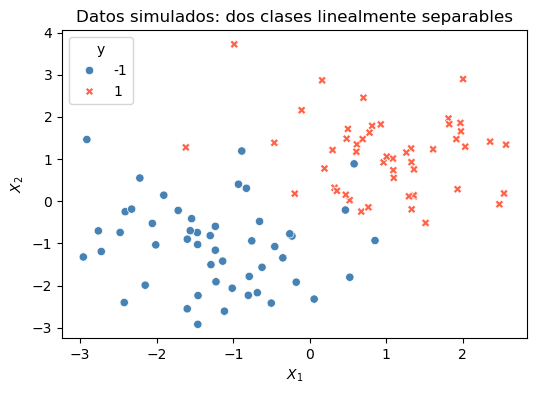

In [ ]:
np.random.seed(42)
n_sim = 100
x1 = np.concatenate([np.random.normal(loc=-1, size=int(n_sim/2)), np.random.normal(loc=1, size=int(n_sim/2))])
x2 = np.concatenate([np.random.normal(loc=-1, size=int(n_sim/2)), np.random.normal(loc=1, size=int(n_sim/2))])
y  = np.repeat(['-1', '1'], int(n_sim/2))

dat_svm = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

# Gráfico de datos simulados 
plt.figure(figsize=(6, 4))
sns.scatterplot(data=dat_svm, x='x1', y='x2', hue='y', style='y', palette=['steelblue', 'tomato'])
plt.title("Datos simulados: dos clases linealmente separables")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.show()

# 2.1.1. Ajuste con kernel lineal

In [ ]:
mod_svm_lin = SVC(kernel='linear', C=1.0)
mod_svm_lin.fit(dat_svm[['x1', 'x2']], dat_svm['y'])

print("Número de vectores de soporte por clase:", mod_svm_lin.n_support_)

Número de vectores de soporte por clase: [8 7]


In [ ]:
pred_lin = mod_svm_lin.predict(dat_svm[['x1', 'x2']])
acc_lin = accuracy_score(dat_svm['y'], pred_lin)
cm_lin = confusion_matrix(dat_svm['y'], pred_lin, labels=['-1', '1'])

print(f"Accuracy en muestra de entrenamiento: {round(acc_lin, 4)}")
print("\nMatriz de confusión - SVM Lineal (datos simulados):")
pd.DataFrame(cm_lin, index=['Ref -1', 'Ref 1'], columns=['Pred -1', 'Pred 1'])

Accuracy en muestra de entrenamiento: 0.95

Matriz de confusión - SVM Lineal (datos simulados):


,Pred -1,Pred 1
Ref -1,46,4
Ref 1,1,49


# 2.1.2. Visualizacion de la frontera de decision

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


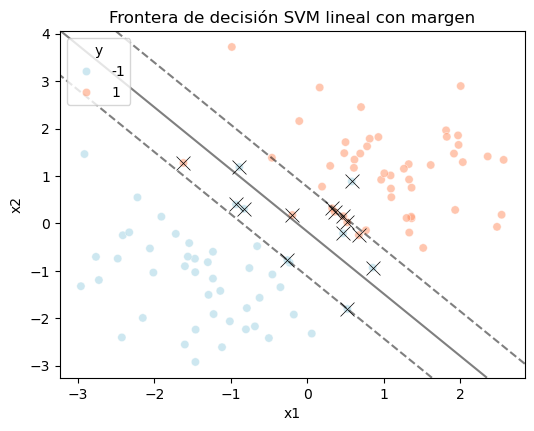

In [ ]:
def plot_svc_decision(model, df):
    plt.figure(figsize=(6, 4.5))
    # Dibujar puntos
    sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette=['html_blue' if False else 'lightblue', 'lightsalmon'], alpha=0.6)
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Grilla para evaluar el modelo
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    P = model.decision_function(xy).reshape(XX.shape)
    
    # Fronteras y márgenes
    ax.contour(XX, YY, P, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    # Destacar vectores de soporte
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],s=100, linewidth=0.5, marker='x', color='black', label='Vectores de Soporte')
    plt.title("Frontera de decisión SVM lineal con margen")
    plt.show()

plot_svc_decision(mod_svm_lin, dat_svm)

Los puntos marcados con × son los vectores de soporte que definen el margen. Todos los demas puntos (◦) no
influyen en la construccion del hiperplano.

# 2.2. Efecto del parametro C
El parametro C controla el trade-off entre maximizar el margen y penalizar las clasificaciones erroneas. Valores pequenos de C permiten mayor numero de errores (margen mas amplio); valores grandes penalizan los errores mas fuertemente (margen mas estrecho):

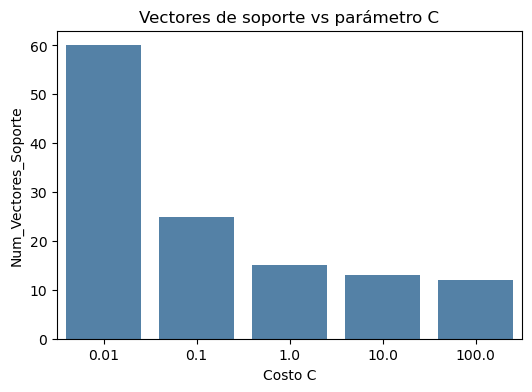

Tabla de número de vectores de soporte por valor de C:


,Costo C,Num_Vectores_Soporte
0,0.01,60
1,0.10,25
2,1.00,15
3,10.00,13
4,100.00,12


In [ ]:
costos = [0.01, 0.1, 1, 10, 100]
n_sv_vec = []

for C in costos:
    mod = SVC(kernel='linear', C=C)
    mod.fit(dat_svm[['x1', 'x2']], dat_svm['y'])
    n_sv_vec.append(sum(mod.n_support_))

df_costo = pd.DataFrame({'Costo C': costos, 'Num_Vectores_Soporte': n_sv_vec})

# Gráfico de barras del número de vectores de soporte por costo
plt.figure(figsize=(6, 4))
sns.barplot(data=df_costo, x='Costo C', y='Num_Vectores_Soporte', color='steelblue')
plt.title("Vectores de soporte vs parámetro C")
plt.show()

print("Tabla de número de vectores de soporte por valor de C:")
df_costo

# 2.3. Seleccion del costo con validacion cruzada: tune
La funcion GridSearchCV() realiza busqueda en grilla con validacion cruzada para seleccionar el mejor valor de C:

In [ ]:
np.random.seed(123)
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}

grid_lin = GridSearchCV(
    SVC(kernel='linear'), 
    param_grid, 
    cv=KFold(n_splits=5, shuffle=True, random_state=123), 
    scoring='accuracy'
)
grid_lin.fit(dat_svm[['x1', 'x2']], dat_svm['y'])

print("Mejor costo encontrado:", grid_lin.best_params_)

# Formatear performances
perf_lin = pd.DataFrame(grid_lin.cv_results_)[['param_C', 'mean_test_score']]
perf_lin.columns = ['Costo C', 'Accuracy Promedio CV']
perf_lin

Mejor costo encontrado: {'C': 0.01}


,Costo C,Accuracy Promedio CV
0,0.01,0.95
1,0.1,0.94
2,1,0.95
3,5,0.93
4,10,0.94


# 2.4. SVM con kernel radial (RBF)

Cuando las clases no son linealmente separables, se usa un kernel radial $K(u,v)=exp\lbrace-\gamma||u-v||^2\rbrace$ cuyo parámetro $\gamma$ controla la suavidad de la frontera:

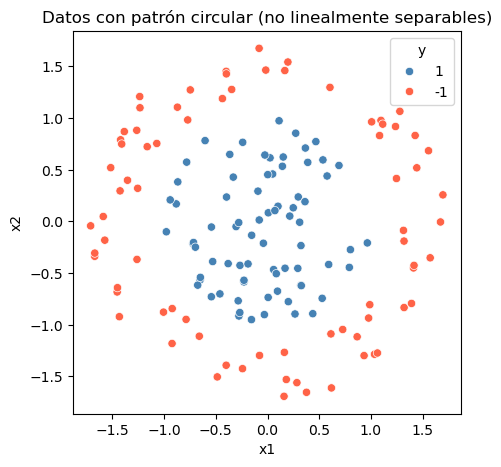

In [ ]:
np.random.seed(99)
n_c = 150
r1 = np.sqrt(np.random.uniform(0, 1, int(n_c/2)))
theta1 = np.random.uniform(0, 2*np.pi, int(n_c/2))
r2 = np.sqrt(np.random.uniform(1.5, 3, int(n_c/2)))
theta2 = np.random.uniform(0, 2*np.pi, int(n_c/2))

dat_circ = pd.DataFrame({
    'x1': np.concatenate([r1*np.cos(theta1), r2*np.cos(theta2)]),
    'x2': np.concatenate([r1*np.sin(theta1), r2*np.sin(theta2)]),
    'y': np.repeat(['1', '-1'], int(n_c/2))
})

plt.figure(figsize=(5, 5))
sns.scatterplot(data=dat_circ, x='x1', y='x2', hue='y', palette=['strict_blue' if False else 'steelblue', 'tomato'])
plt.title("Datos con patrón circular (no linealmente separables)")
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
param_grid_rbf = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.5, 1, 2]
}

grid_rbf = GridSearchCV(
    SVC(kernel='rbf'), 
    param_grid_rbf, 
    cv=KFold(n_splits=5, shuffle=True, random_state=123), 
    scoring='accuracy'
)
grid_rbf.fit(dat_circ[['x1', 'x2']], dat_circ['y'])
grid_rbf
print("Mejores hiperparámetros encontrados:", grid_rbf.best_params_)
# Extraemos los resultados completos de la Validación Cruzada
results_rbf = pd.DataFrame(grid_rbf.cv_results_)

# Seleccionamos las columnas equivalentes a las de R que son cost, gamma, error, dispersion
perf_rbf = pd.DataFrame({
    'cost': results_rbf['param_C'],
    'gamma': results_rbf['param_gamma'],
    'error': 1 - results_rbf['mean_test_score'],
    'dispersion': results_rbf['std_test_score']
})

print("Cuadro 7: Error CV (5-fold) - kernel radial")
# Mostramos la tabla completa con el mismo ordenamiento
perf_rbf.style.format({
    'cost': '{:.1f}',
    'gamma': '{:.1f}',
    'error': '{:.4f}',
    'dispersion': '{:.4f}'
})

Mejores hiperparámetros encontrados: {'C': 1, 'gamma': 0.5}
Cuadro 7: Error CV (5-fold) - kernel radial


,cost,gamma,error,dispersion
0,0.1,0.1,0.5667,0.0298
1,0.1,0.5,0.0400,0.0389
2,0.1,1.0,0.0600,0.0249
3,0.1,2.0,0.0667,0.0365
4,1.0,0.1,0.0200,0.0267
5,1.0,0.5,0.0000,0.0000
6,1.0,1.0,0.0000,0.0000
7,1.0,2.0,0.0000,0.0000
8,10.0,0.1,0.0000,0.0000
9,10.0,0.5,0.0000,0.0000


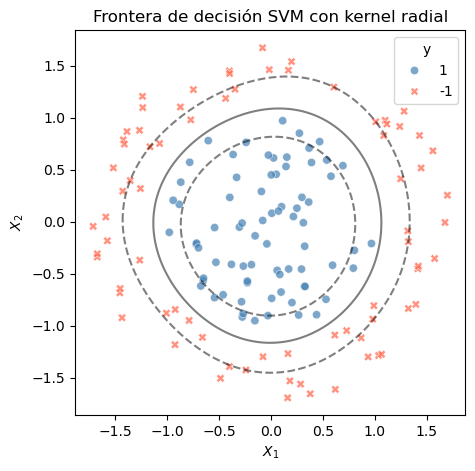

In [ ]:
def plot_svc_radial_decision(model, df):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x='x1', y='x2', hue='y', style='y', 
                    palette=['steelblue', 'tomato'], alpha=0.7)
    #ejes
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Creaamos una grilla  para poder reprresentar la curva no lineal
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    xy_df = pd.DataFrame(xy, columns=['x1', 'x2'])
    P = model.decision_function(xy_df).reshape(XX.shape)
    ax.contour(XX, YY, P, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    
    plt.title("Frontera de decisión SVM con kernel radial")
    plt.xlabel("$X_1$")
    plt.ylabel("$X_2$")
    plt.gca().set_aspect('equal', adjustable='box') # Mantiene la proporción circular
    plt.show()
# Usamos el mejor modelo generado por el GridSearchCV de la sección 2.4
plot_svc_radial_decision(grid_rbf.best_estimator_, dat_circ)

# 2.5. SVM con datos reales: Default (ISLR2)

In [ ]:
train_d, test_d = train_test_split(Default, test_size=0.3, random_state=123)

scaler_svm = StandardScaler()
X_train_d = scaler_svm.fit_transform(train_d[['balance', 'income']])
X_test_d  = scaler_svm.transform(test_d[['balance', 'income']])

y_train_d = train_d['default']
y_test_d  = test_d['default']

# Ajustamos una SVM radial con parámetros estándar emulando caret
mod_svm_def = SVC(kernel='rbf', C=1.0, gamma='scale')
mod_svm_def.fit(X_train_d, y_train_d)

pred_svm_def = mod_svm_def.predict(X_test_d)
cm_svm_def = confusion_matrix(y_test_d, pred_svm_def, labels=["No", "Yes"])
tn, fp, fn, tp = cm_svm_def.ravel()

print(f"Accuracy: {round((tp+tn)/(tp+tn+fp+fn), 4)}")
print(f"Sensibilidad: {round(tp/(tp+fn), 4)}")
print(f"Especificidad: {round(tn/(tn+fp), 4)}")
print("\nMatriz de Confusión - SVM Radial sobre Default (test 30%):")
pd.DataFrame(cm_svm_def, index=['Ref No', 'Ref Yes'], columns=['Pred No', 'Pred Yes'])

Accuracy: 0.9733
Sensibilidad: 0.2245
Especificidad: 0.9986

Matriz de Confusión - SVM Radial sobre Default (test 30%):


,Pred No,Pred Yes
Ref No,2898,4
Ref Yes,76,22


# 3. Clasificacion con Clases Desbalanceadas

El conjunto $\textit{Default}$ tiene solo $\approx 3.3\%$ de casos positivos (Yes), ilustrando el problema de clases desbalanceadas. Se aplican las técnicas presentadas en clases.

# 3.1 Exploración del desbalance

In [ ]:
resumen_desbalance = Default['default'].value_counts()
proporcion_desbalance = Default['default'].value_counts(normalize=True)

pd.DataFrame({
    'n': resumen_desbalance,
    'proporción': proporcion_desbalance.round(3)
})

,n,proporción
default,,
No,9667,0.967
Yes,333,0.033


# 3.2 Modelo Base sin balancear

In [ ]:
# Regresión logística clásica sin penalización (C gigante para aproximar GLM tradicional)
from sklearn.linear_model import LogisticRegression
mod_base = LogisticRegression(C=1e10)
mod_base.fit(train_d[['balance', 'income']], train_d['default'])

pred_base = mod_base.predict(test_d[['balance', 'income']])
cm_base = confusion_matrix(test_d['default'], pred_base, labels=["No", "Yes"])
tn, fp, fn, tp = cm_base.ravel()

print(f"Sensibilidad (modelo sin balancear): {round(tp / (tp + fn), 4)}")
print(f"Especificidad (modelo sin balancear): {round(tn / (tn + fp), 4)}")
print(f"Matriz de confusión:")
pd.DataFrame(cm_base, index=['No', 'Yes'], columns=['No', 'Yes'])

Sensibilidad (modelo sin balancear): 0.2857
Especificidad (modelo sin balancear): 0.9976
Matriz de confusión:


,No,Yes
No,2895,7
Yes,70,28


# 3.3. Undersampling aleatorio

Se reduce la clase mayoritaria hasta igualar la clase minoritaria:


In [ ]:
train_yes = train_d[train_d['default'] == "Yes"]
train_no  = train_d[train_d['default'] == "No"]

# Muestreamos la clase mayoritaria de forma aleatoria
train_no_under = train_no.sample(n=len(train_yes), random_state=123)
train_under = pd.concat([train_yes, train_no_under])

print("Distribución tras undersampling:")
print(train_under['default'].value_counts())

mod_under = LogisticRegression(C=1e10).fit(train_under[['balance', 'income']], train_under['default'])
pred_under = mod_under.predict(test_d[['balance', 'income']])
cm_under = confusion_matrix(test_d['default'], pred_under, labels=["No", "Yes"])
print(f"Matriz de confusión:")
pd.DataFrame(cm_under, index=['No', 'Yes'], columns=['No', 'Yes'])

Distribución tras undersampling:
default
Yes    235
No     235
Name: count, dtype: int64
Matriz de confusión:


,No,Yes
No,2478,424
Yes,10,88


# 3.4. Oversampling aleatorio

Se replica la clase minoritaria hasta igualar la clase mayoritaria:

In [ ]:
train_yes_over = train_yes.sample(n=len(train_no), replace=True, random_state=123)
train_over = pd.concat([train_no, train_yes_over])

print("Distribución tras oversampling:")
print(train_over['default'].value_counts())

mod_over = LogisticRegression(C=1e10).fit(train_over[['balance', 'income']], train_over['default'])
pred_over = mod_over.predict(test_d[['balance', 'income']])
cm_over = confusion_matrix(test_d['default'], pred_over, labels=["No", "Yes"])
print(f"Matriz de confusión:")
pd.DataFrame(cm_over, index=['No', 'Yes'], columns=['No', 'Yes'])

Distribución tras oversampling:
default
No     6765
Yes    6765
Name: count, dtype: int64
Matriz de confusión:


,No,Yes
No,2482,420
Yes,9,89


# 3.5. SMOTE (Synthetic Minority Oversampling Technique)

SMOTE crea ejemplos sinteticos de la clase minoritaria interpolando entre observaciones existentes y sus
k-vecinos mas cercanos:

$$S_i^j=X_j+\lambda(X_i^j-X_j),\;\;\lambda\sim U(0,1)\;\;i=1,...,k $$

In [ ]:
smote = SMOTE(random_state=123)
X_train_res, y_train_res = smote.fit_resample(train_d[['balance', 'income']], train_d['default'])

print("Distribución tras SMOTE:")
print(y_train_res.value_counts())

mod_smote = LogisticRegression(C=1e10).fit(X_train_res, y_train_res)
pred_smote = mod_smote.predict(test_d[['balance', 'income']])
cm_smote = confusion_matrix(test_d['default'], pred_smote, labels=["No", "Yes"])
print(f"Matriz de confusión:")
pd.DataFrame(cm_smote, index=['No', 'Yes'], columns=['No', 'Yes'])

Distribución tras SMOTE:
default
No     6765
Yes    6765
Name: count, dtype: int64
Matriz de confusión:


,No,Yes
No,2530,372
Yes,11,87


# 3.6. Probabilidad de corte óptima

Se busca el corte que iguala la sensibilidad y la especificidad:

Probabilidad de corte óptima (Sens = Spec): 0.05


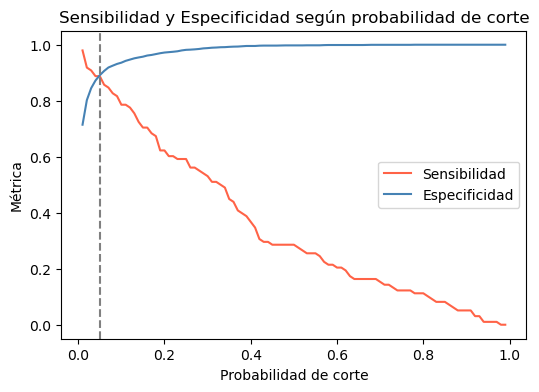

In [ ]:
# Obtener probabilidades estimadas para la clase "Yes"
idx_yes = np.where(mod_base.classes_ == "Yes")[0][0]
pi_base = mod_base.predict_proba(test_d[['balance', 'income']])[:, idx_yes]

cortes = np.arange(0.01, 1.0, 0.01)
sens_v, spec_v = [], []

for c in cortes:
    pred_c = np.where(pi_base >= c, "Yes", "No")
    cm_c = confusion_matrix(test_d['default'], pred_c, labels=["No", "Yes"])
    tn, fp, fn, tp = cm_c.ravel()
    sens_v.append(tp / (tp + fn))
    spec_v.append(tn / (tn + fp))

dif = np.abs(np.array(sens_v) - np.array(spec_v))
corte_opt = cortes[np.argmin(dif)]

print(f"Probabilidad de corte óptima (Sens = Spec): {round(corte_opt, 4)}")
#grafica
plt.figure(figsize=(6, 4))
plt.plot(cortes, sens_v, label="Sensibilidad", color="tomato")
plt.plot(cortes, spec_v, label="Especificidad", color="steelblue")
plt.axvline(corte_opt, linestyle="dashed", color="gray")
plt.title("Sensibilidad y Especificidad según probabilidad de corte")
plt.xlabel("Probabilidad de corte")
plt.ylabel("Métrica")
plt.legend()
plt.show()

In [ ]:
pred_opt = np.where(pi_base >= corte_opt, "Yes", "No")
cm_opt = confusion_matrix(test_d['default'], pred_opt, labels=["No", "Yes"])
print(f"Matriz de confusión")
pd.DataFrame(cm_opt,index=['No', 'Yes'], columns=['No', 'Yes'])

Matriz de confusión


,No,Yes
No,2586,316
Yes,11,87


# 3.7. Resumen comparativo de tecnicas

In [ ]:
def extraer_metricas(cm):
    tn, fp, fn, tp = cm.ravel()
    return [
        round((tp + tn) / (tp + tn + fp + fn), 4),
        round(tp / (tp + fn), 4),
        round(tn / (tn + fp), 4)
    ]

resumen_db = pd.DataFrame([
    extraer_metricas(cm_base),
    extraer_metricas(cm_under),
    extraer_metricas(cm_over),
    extraer_metricas(cm_smote),
    extraer_metricas(cm_opt)
], columns=['Accuracy', 'Sensibilidad', 'Especificidad'])

resumen_db.insert(0, 'Técnica', [
    "Sin balanceo (p=0.5)", 
    "Undersampling aleatorio",
    "Oversampling aleatorio", 
    "SMOTE",
    f"Corte óptimo (p={round(corte_opt,2)})"
])

print("Comparación de técnicas para clases desbalanceadas - Default (test 30%):")
resumen_db

Comparación de técnicas para clases desbalanceadas - Default (test 30%):


,Técnica,Accuracy,Sensibilidad,Especificidad
0,Sin balanceo (p=0.5),0.9743,0.2857,0.9976
1,Undersampling aleatorio,0.8553,0.8980,0.8539
2,Oversampling aleatorio,0.8570,0.9082,0.8553
3,SMOTE,0.8723,0.8878,0.8718
4,Corte óptimo (p=0.05),0.8910,0.8878,0.8911


Las tecnicas de balanceo mejoran significativamente la sensibilidad a costa de reducir la especificidad. La eleccion de tecnica depende del costo relativo de los errores en cada problema especifico

# 4. Ejercicio Propuesto

Considere la base de datos $Caravan$ de $ISLR2$, que contiene información sobre **5822** clientes de una aseguradora holandesa. La variable respuesta es Purchase (Yes = compró un seguro de caravana, No = no compró), y hay 85 predictores sociodemográficos y de pólizas.

Defina el conjunto de entrenamiento $\mathcal{T}$ con las primeras **4000** observaciones y el conjunto de prueba $\mathcal{T}^{*}$ con las restantes **1822**, en línea con la convención del libro de texto (Hastie et al., 2008).

a) Explore la distribución de **Purchase** en $\mathcal{T}$. ¿Existe desbalance? Calcule la proporción de la clase positiva.

b) Estandarice los predictores numéricos usando **únicamente los parámetros de $\mathcal{T}$** (media y desviación estándar) y aplique la misma transformación a $\mathcal{T}^{*}$. Ajuste un clasificador *k*-NN para $k \in \{1,3,5,10,20,50\}$ y reporte **Accuracy**, **Sensibilidad** y **Especificidad** evaluados sobre $\mathcal{T}^{*}$. Seleccione el $k$ que maximice la Sensibilidad sin que la Especificidad caiga por debajo de **0.80**.

c) Ajuste una **SVM con kernel radial** usando validación cruzada **5-fold** sobre $\mathcal{T}$ para seleccionar $C \in \{0.1,1,10\}$ y $\gamma \in \{0.01,0.1,1\}$. Evalúe el mejor modelo en $\mathcal{T}^{*}$ y compare con el *k*-NN óptimo del literal (b) en términos de **Accuracy**, **Sensibilidad**, **Especificidad** y **AUC**.

d) Dado el desbalance encontrado en (a), aplique **SMOTE** y **undersampling aleatorio** al conjunto $\mathcal{T}$, vuelva a ajustar la SVM radial con los mismos hiperparámetros y compare las métricas en $\mathcal{T}^{*}$ con el modelo sin balanceo.

e) Para el mejor modelo identificado en (c) o (d), encuentre la **probabilidad de corte óptima** $p^{*}$ igualando Sensibilidad y Especificidad sobre $\mathcal{T}^{*}$. Interprete el resultado en el contexto del problema (costo de no detectar un comprador potencial).

f) Elabore una **tabla resumen comparativa** con todos los clasificadores ajustados (k-NN óptimo, SVM sin balanceo, SVM con SMOTE, SVM con undersampling, SVM con corte óptimo). Indique cuál recomendaría y justifique en función de las métricas y del contexto del negocio.

# Referencias
- [Hastie et al.(2008)] Trevor Hastie, Robert Tibshirani and Jerome Friedman (2008) The Elements of Statistical
Learning: Data Mining, Inference, and Prediction. Springer Series in Statistics.
- [James et al.(2021)] Gareth James, Daniela Witten, Trevor Hastie and Robert Tibshirani (2021) An Intro-
duction to Statistical Learning with Applications in R, 2nd edition. Springer Series in Statistics